In [1]:

# ✅ Keratoconus Detection with MobileNetV2 - Google Colab

# Step 1: Install and Setup Kaggle API
!pip install -q kaggle opencv-python scikit-learn gradio

from google.colab import files
files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 2: Download dataset
!kaggle datasets download -d elmehdi12/keratoconus-detection
!unzip -q keratoconus-detection.zip -d keratoconus-data

# Step 3: Import libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import os

# Step 4: Set paths
train_path = "/content/keratoconus-data/Train_Validation sets/Train_Validation sets"
test_path = "/content/keratoconus-data/Independent Test Set/Independent Test Set"

# Step 5: Image generators
datagen = ImageDataGenerator(rescale=1./255)

train = datagen.flow_from_directory(train_path, target_size=(224,224), color_mode="rgb",
                                    batch_size=32, class_mode="sparse")
test = datagen.flow_from_directory(test_path, target_size=(224,224), color_mode="rgb",
                                   batch_size=32, class_mode="sparse")

# Step 6: Build MobileNetV2 model
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Step 7: Callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-6)

# Step 8: Train model
history = model.fit(train, validation_data=test, epochs=20, callbacks=[early_stopping, reduce_lr])

# Step 9: Save model
model.save("mobilenetv2_keratoconus.h5")

# Step 10: Gradio prediction UI
import gradio as gr
from PIL import Image

eye_dict = {0: "Keratoconus", 1: "Normal", 2: "Suspect"}

def predict_eye(image):
    img = image.convert("RGB").resize((224, 224))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    pred = model.predict(img)
    class_id = np.argmax(pred)
    confidence = pred[0][class_id]
    return f"Dự đoán: {eye_dict[class_id]} (Độ tin cậy: {confidence:.2%})"

gr.Interface(fn=predict_eye,
             inputs=gr.Image(type="pil"),
             outputs="text",
             title="Chẩn đoán Keratoconus từ ảnh mắt").launch()


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/elmehdi12/keratoconus-detection
License(s): other
  0% 0.00/48.6M [00:00<?, ?B/s]
100% 48.6M/48.6M [00:00<00:00, 1.73GB/s]
Found 2961 images belonging to 3 classes.
Found 1050 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


93/93 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.4616 - loss: 1.2013 - val_accuracy: 0.5257 - val_loss: 0.9865 - learning_rate: 0.0010
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.5709 - loss: 0.9011 - val_accuracy: 0.5695 - val_loss: 0.9735 - learning_rate: 0.0010
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.6325 - loss: 0.7752 - val_accuracy: 0.5667 - val_loss: 0.9946 - learning_rate: 0.0010
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.6436 - loss: 0.7548 - val_accuracy: 0.5638 - val_loss: 0.9957 - learning_rate: 0.0010
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.6556 - loss: 0.7278 - val_accuracy: 0.5762 - val_loss: 0.9977 - learning_rate: 0.0010
Epoch 6/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.6991 - loss: 0.6735 - val_accuracy: 0.5600 - val_loss: 1.1070 - learning_rate: 0.0010
Epoch 7/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.7033 - loss: 0.6657 - val_accuracy: 0.56

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c0e6e35f3ea04a909.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [2]:
import gradio as gr
from PIL import ImageDraw, ImageFont

def predict_many_images(files):
    results = []
    for file in files:
        image = Image.open(file).convert("RGB").resize((224, 224))
        img_array = np.array(image) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        pred = model.predict(img_array)
        class_id = np.argmax(pred)
        confidence = pred[0][class_id]
        label = f"{eye_dict[class_id]} ({confidence:.2%})"

        # Vẽ label lên ảnh
        draw = ImageDraw.Draw(image)
        font = ImageFont.load_default()
        draw.text((10, 10), label, fill="red", font=font)

        results.append(image)
    return results

gr.Interface(
    fn=predict_many_images,
    inputs=gr.File(file_types=["image"], file_count="multiple", label="Tải nhiều ảnh"),
    outputs=gr.Gallery(label="Kết quả dự đoán", columns=3, height=300),
    title="Chẩn đoán Keratoconus từ ảnh bản đồ giác mạc",
    description="Tải lên nhiều ảnh. Hệ thống sẽ trả về ảnh có nhãn dự đoán ghi trực tiếp lên ảnh."
).launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ff65a53cbc36158ad1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


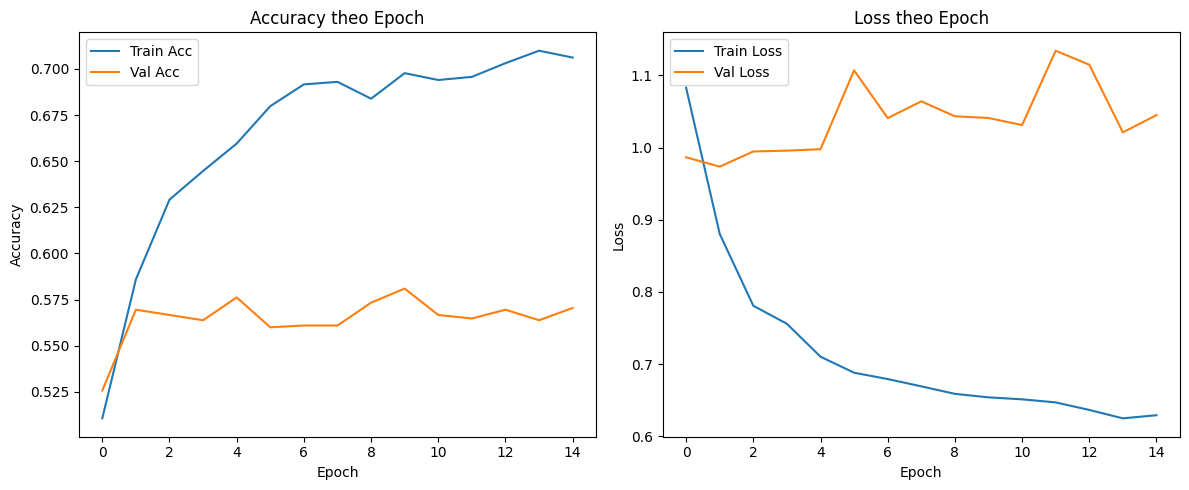

In [3]:
# Biểu đồ Accuracy và Loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy theo Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss theo Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 990ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 856ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 969ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 965ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 963ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 952ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 930ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 790ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 965ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 829ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 925ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/ste

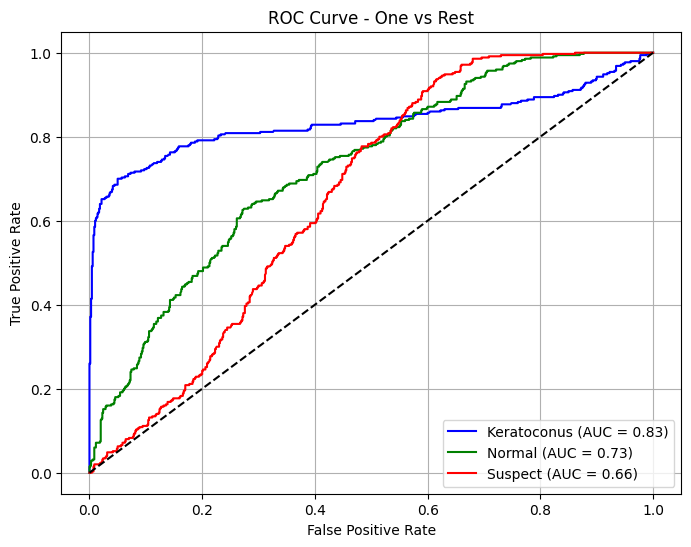

In [4]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels
n_classes = 3
y_true = []
y_pred = []

test.reset()
for i in range(len(test)):
    x, y = test[i]
    preds = model.predict(x)
    y_true.extend(y)
    y_pred.extend(preds)
    if (i+1)*test.batch_size >= test.samples:
        break

y_true = label_binarize(y_true, classes=[0, 1, 2])
y_pred = np.array(y_pred)

# ROC AUC cho từng lớp
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Vẽ đường cong ROC
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
labels = ['Keratoconus', 'Normal', 'Suspect']
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - One vs Rest')
plt.legend(loc='lower right')
plt.grid()
plt.show()


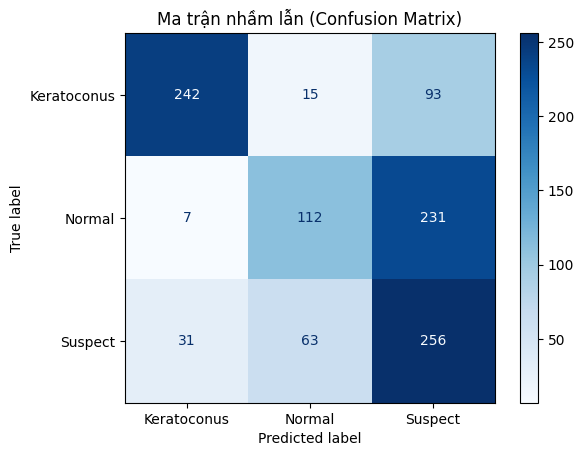

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Keratoconus", "Normal", "Suspect"])
disp.plot(cmap='Blues')
plt.title("Ma trận nhầm lẫn (Confusion Matrix)")
plt.show()


In [6]:
from sklearn.metrics import classification_report

print(classification_report(y_true_labels, y_pred_labels, target_names=["Keratoconus", "Normal", "Suspect"]))


              precision    recall  f1-score   support

 Keratoconus       0.86      0.69      0.77       350
      Normal       0.59      0.32      0.41       350
     Suspect       0.44      0.73      0.55       350

    accuracy                           0.58      1050
   macro avg       0.63      0.58      0.58      1050
weighted avg       0.63      0.58      0.58      1050



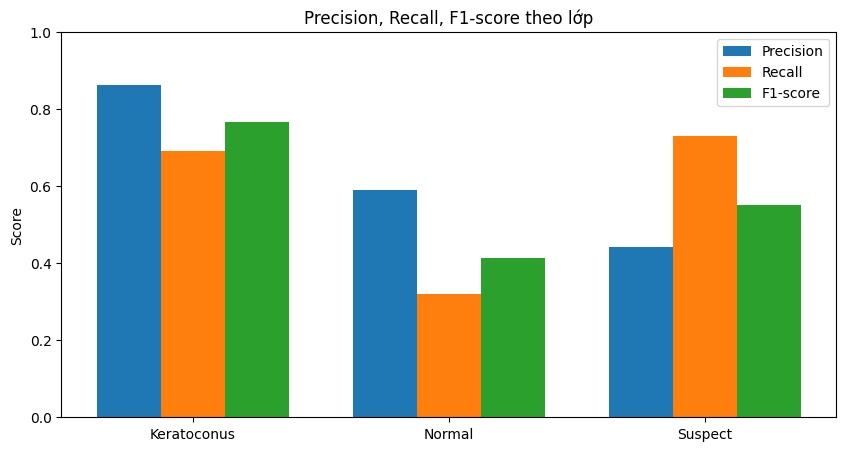

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score

classes = ["Keratoconus", "Normal", "Suspect"]
precision = precision_score(y_true_labels, y_pred_labels, average=None)
recall = recall_score(y_true_labels, y_pred_labels, average=None)
f1 = f1_score(y_true_labels, y_pred_labels, average=None)

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Precision, Recall, F1-score theo lớp')
plt.legend()
plt.show()


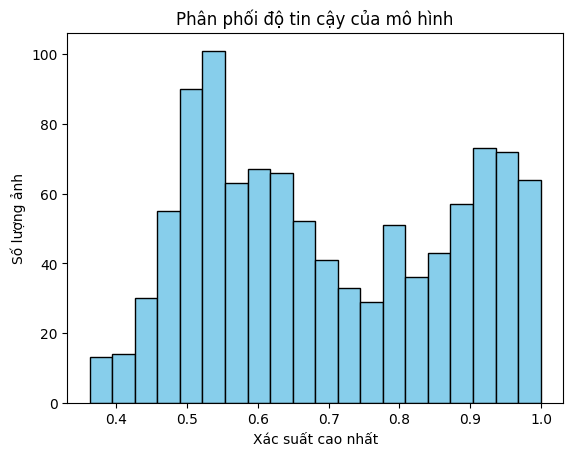

In [8]:
pred_probs = np.max(y_pred, axis=1)
plt.hist(pred_probs, bins=20, color='skyblue', edgecolor='black')
plt.title('Phân phối độ tin cậy của mô hình')
plt.xlabel('Xác suất cao nhất')
plt.ylabel('Số lượng ảnh')
plt.show()


In [9]:
# Đánh giá mô hình trên tập test
loss, accuracy = model.evaluate(test)
print(f"Độ chính xác trên tập kiểm tra: {accuracy:.2%}")


33/33 ━━━━━━━━━━━━━━━━━━━━ 32s 959ms/step - accuracy: 0.5815 - loss: 1.0788
Độ chính xác trên tập kiểm tra: 58.10%


In [ ]:
from sklearn.metrics import classification_report

# Dự đoán trên tập test
test.reset()
y_true = []
y_pred = []

for i in range(len(test)):
    x, y = test[i]
    preds = model.predict(x)
    y_true.extend(y)
    y_pred.extend(np.argmax(preds, axis=1))
    if (i+1)*test.batch_size >= test.samples:
        break

# In báo cáo phân loại
print(classification_report(y_true, y_pred, target_names=["Keratoconus", "Normal", "Suspect"]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [10]:
import pandas as pd
from collections import Counter

# Phân bố lớp trong tập huấn luyện
train_class_counts = Counter(train.classes)
train_class_names = list(train.class_indices.keys())
train_distribution = {train_class_names[i]: train_class_counts[i] for i in range(len(train_class_names))}

# Phân bố lớp trong tập kiểm tra
test_class_counts = Counter(test.classes)
test_class_names = list(test.class_indices.keys())
test_distribution = {test_class_names[i]: test_class_counts[i] for i in range(len(test_class_names))}

# Hiển thị dưới dạng bảng
df_distribution = pd.DataFrame({
    "Lớp": train_class_names,
    "Số lượng ảnh Train": [train_distribution.get(cls, 0) for cls in train_class_names],
    "Số lượng ảnh Test": [test_distribution.get(cls, 0) for cls in train_class_names]
})

print(df_distribution)


           Lớp  Số lượng ảnh Train  Số lượng ảnh Test
0  Keratoconus                1050                350
1       Normal                1050                350
2      Suspect                 861                350


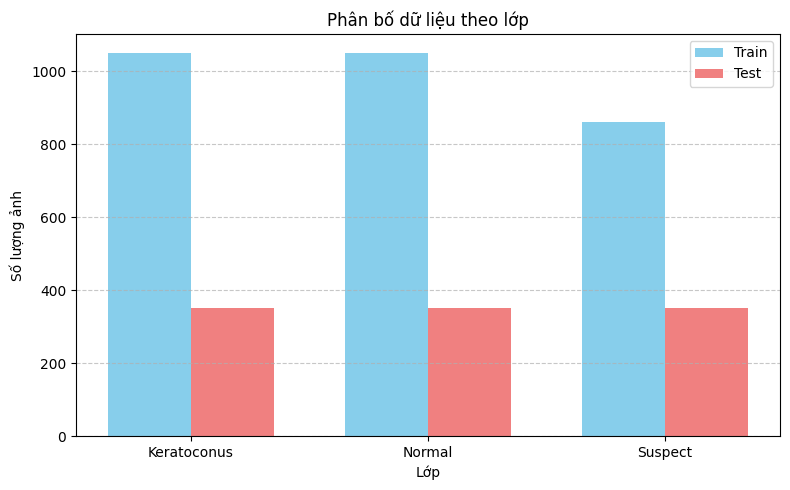

In [11]:
import matplotlib.pyplot as plt

# Dữ liệu từ bảng phân phối
labels = df_distribution["Lớp"]
train_counts = df_distribution["Số lượng ảnh Train"]
test_counts = df_distribution["Số lượng ảnh Test"]

x = range(len(labels))
width = 0.35  # Độ rộng của cột

plt.figure(figsize=(8, 5))
plt.bar(x, train_counts, width=width, label='Train', color='skyblue')
plt.bar([i + width for i in x], test_counts, width=width, label='Test', color='lightcoral')

plt.xlabel("Lớp")
plt.ylabel("Số lượng ảnh")
plt.title("Phân bố dữ liệu theo lớp")
plt.xticks([i + width / 2 for i in x], labels)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
